# Preprocessing Transactions

This file preprocesses the transaction data 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import zipfile
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from datetime import datetime, timedelta

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/11 16:32:11 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/11 16:32:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/11 16:32:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Unzip the data files
zip_file_path = [
    "../data/project-2-bnpl-tables-part1.zip",
    "../data/project-2-bnpl-tables-part2.zip",
    "../data/project-2-bnpl-tables-part3.zip",
    "../data/project-2-bnpl-tables-part4.zip"
]

for zip_path in zip_file_path:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("../data/")
    

In [4]:
transactions1 = spark.read.parquet(".././data/tables/transactions_20210228_20210827_snapshot")
transactions2 = spark.read.parquet(".././data/tables/transactions_20210828_20220227_snapshot")
transactions3 = spark.read.parquet(".././data/tables/transactions_20220228_20220828_snapshot")

transactions1.write.mode('overwrite').parquet('.././data/landing/transactions/transactions1')
transactions2.write.mode('overwrite').parquet('.././data/landing/transactions/transactions2')
transactions3.write.mode('overwrite').parquet('.././data/landing/transactions/transactions3')

In [5]:
transactions = transactions1.union(transactions2).union(transactions3)

transactions.show()
transactions.count()

+-------+------------+------------------+--------------------+--------------+
|user_id|merchant_abn|      dollar_value|            order_id|order_datetime|
+-------+------------+------------------+--------------------+--------------+
|  18478| 62191208634|63.255848959735246|949a63c8-29f7-4ab...|    2021-08-20|
|      2| 15549624934| 130.3505283105634|6a84c3cf-612a-457...|    2021-08-20|
|  18479| 64403598239|120.15860593212783|b10dcc33-e53f-425...|    2021-08-20|
|      3| 60956456424| 136.6785200286976|0f09c5a5-784e-447...|    2021-08-20|
|  18479| 94493496784| 72.96316578355305|f6c78c1a-4600-4c5...|    2021-08-20|
|      3| 76819856970|  448.529684285612|5ace6a24-cdf0-4aa...|    2021-08-20|
|  18479| 67609108741|  86.4040605836911|d0e180f0-cb06-42a...|    2021-08-20|
|      3| 34096466752| 301.5793450525113|6fb1ff48-24bb-4f9...|    2021-08-20|
|  18482| 70501974849| 68.75486276223054|8505fb33-b69a-412...|    2021-08-20|
|      4| 49891706470| 48.89796461900801|ed11e477-b09f-4ae...|  

14195505

In [6]:
transactions.write.mode('overwrite').parquet('.././data/raw/transactions/full_transactions')
transactions = spark.read.parquet(".././data/raw/transactions/full_transactions")
transactions.show(truncate = False)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|11139  |96152467973 |16.213590228273233|785b0080-9e4b-471a-9b1f-6a8a9dc535c2|2022-08-20    |
|1      |98973094975 |86.97955945703498 |2560f7b0-ee5d-4b3e-bfc2-a00c011ff63c|2022-08-20    |
|11139  |56762458844 |31.513502323509194|0311717b-8b5b-410b-89f3-f6e984b54a30|2022-08-20    |
|1      |89502033586 |124.18468694868491|f8891626-f098-45bf-bd6b-a50d12823338|2022-08-20    |
|11139  |96161808980 |61.620445567668966|d90a421f-f1da-4bff-97ac-47b53fd841fd|2022-08-20    |
|2      |72472909171 |32.26524985312485 |523e0403-b677-4505-a8b8-fb9bce781127|2022-08-20    |
|11139  |91923722701 |11.331586767322225|f45a842b-0366-41d7-87e3-b7dd0fa13bec|2022-08-20    |
|3      |46380096952 |119.80011239189334|58d0f423-037c-43f0-

# Schema

In [7]:
transactions.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



Ensure all datatypes are consistent across tables.

In [8]:
transactions = transactions.withColumn('user_id', F.col('user_id').cast(StringType()))
transactions = transactions.withColumn('merchant_abn', F.col('merchant_abn').cast(StringType()))
transactions.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



# Missing Value Detection

In [9]:
transactions.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in transactions.columns
]).show()

+-------+------------+------------+--------+--------------+
|user_id|merchant_abn|dollar_value|order_id|order_datetime|
+-------+------------+------------+--------+--------------+
|      0|           0|           0|       0|             0|
+-------+------------+------------+--------+--------------+



# Business Filtering Rule

`dollar value` for any transaction needs be greater than 0.

In [10]:
def report_shape(df, label):
    n = df.count()
    print(f"{label}: {n:,} rows")
    return n

n0 = report_shape(transactions, "0. raw transactions")

# --- Business-rule filtering ---
# dollar_value must be strictly positive -- a $0 or negative transaction
# isn't a real purchase (refunds/corrections, if any, aren't modelled here).
step1 = transactions.filter(F.col("dollar_value") > 0)
n1 = report_shape(step1, "1. dollar_value > 0")

clean = step1
print(f"Retained: {n1:,} / {n0:,} ({n1/n0:.1%})")

0. raw transactions: 14,195,505 rows


1. dollar_value > 0: 14,195,505 rows
Retained: 14,195,505 / 14,195,505 (100.0%)


# Outlier Removal

Outlier removal on `dollar_value` (log-N IQR rule). Raw dollar_value is right-skewed (many small purchases, a long tail of large ones), so IQR is computed on log1p(dollar_value) rather than the raw scale. Per the log-N rule: flag values more than k x IQR from the box, where k = sqrt(log n) - 0.5 for n > 100.

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


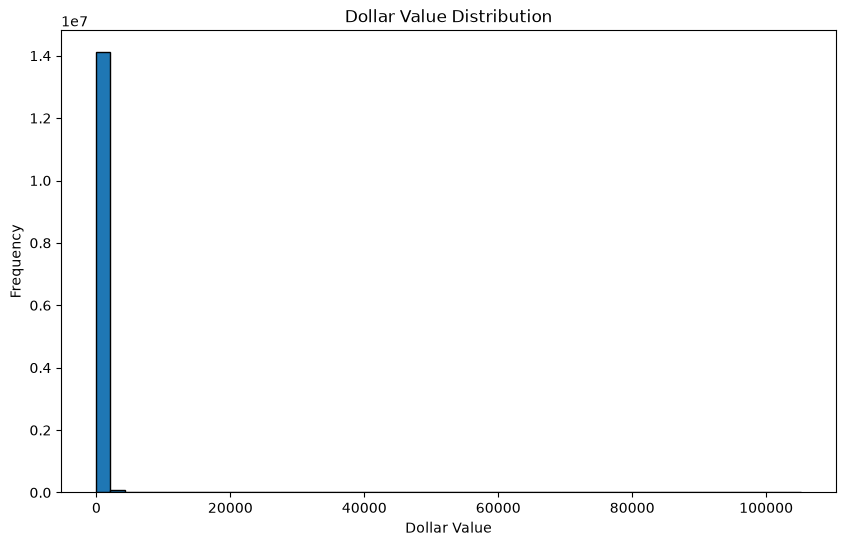

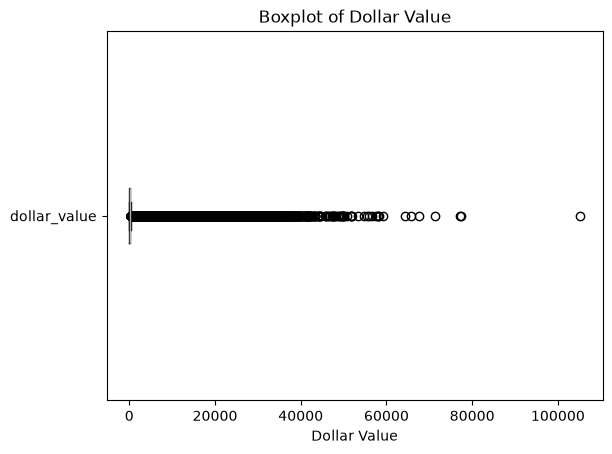

In [11]:
dollar = transactions.select("dollar_value").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(dollar["dollar_value"], bins=50, edgecolor="black")
plt.xlabel("Dollar Value")
plt.ylabel("Frequency")
plt.title("Dollar Value Distribution")
plt.show()

dollar.boxplot(column="dollar_value", vert=False, grid=False)
plt.xlabel("Dollar Value")
plt.title("Boxplot of Dollar Value")
plt.show()

In [12]:
clean = clean.withColumn("log_dollar_value", F.log1p(F.col("dollar_value")))

n_rows = clean.count()
k = np.sqrt(np.log(n_rows)) - 0.5

q1, q3 = clean.approxQuantile("log_dollar_value", [0.25, 0.75], 0.0)
iqr = q3 - q1

lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

print(f"n = {n_rows:,}, k = {k:.4f}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

n_before_outlier = report_shape(clean, "2. before outlier removal")

curated = clean.filter(
    (F.col("log_dollar_value") >= lower_bound) &
    (F.col("log_dollar_value") <= upper_bound)
).drop("log_dollar_value")

n_after_outlier = report_shape(curated, "3. after log-N IQR outlier removal")
print(f"Removed as outliers: {n_before_outlier - n_after_outlier:,}")

print(f"\nTotal retained: {n_after_outlier:,} / {n0:,} ({n_after_outlier/n0:.1%})")

n = 14,195,505, k = 3.5581
Log-scale Q1: 3.3006, Q3: 5.0203, IQR: 1.7196
Log-scale bounds: [-2.8181, 11.1390]


2. before outlier removal: 14,195,505 rows
3. after log-N IQR outlier removal: 14,195,501 rows
Removed as outliers: 4

Total retained: 14,195,501 / 14,195,505 (100.0%)


Store curated transaction dataset

In [13]:
transactions.write.mode("overwrite").parquet("../data/curated/transactions/")

# Join with Consumers data

Join on `user_id` and `order_datetime`.

In [14]:
consumer = spark.read.parquet("../data/curated/df_customers/")
consumer.show(truncate = False)

+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|consumer_id|user_id|order_datetime|fraud_probability |is_same_day_duplicate|name             |address                       |state|postcode|gender|
+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|712975     |5      |2021-10-04    |10.868364868449886|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-01-11    |27.496186536467164|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-02-08    |9.02022421158597  |false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|1331093    |17     |2022-02-14    |9.518525205093667 |false                |Alyssa Wilson    |44353 Natha

In [15]:
consumer.printSchema()
consumer.count() 

root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



34864

In [16]:
transaction_cols = set(transactions.columns)
consumer_cols = set(consumer.columns)

overlapping_cols = transaction_cols & consumer_cols
print(overlapping_cols)

{'user_id', 'order_datetime'}


In [17]:
transactions.count()

14195505

In [18]:
c_transactions = (
    transactions
    .join(
        consumer,
        on=["user_id","order_datetime"],
        how="inner"
    )
)

c_transactions.show()

+-------+--------------+------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+
|user_id|order_datetime|merchant_abn|       dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|          name|             address|state|postcode|gender|
+-------+--------------+------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+
|     58|    2021-11-26| 43725628716|  2684.361417897887|52133cb6-4950-44c...|     838663| 9.241197906604826|                false|Adam Velazquez|  1075 Schultz Track|  NSW|    2403|  Male|
|     58|    2021-11-26| 45629217853|0.19607762574988435|e5b1880d-fb88-4fd...|     838663| 9.241197906604826|                false|Adam Velazquez|  1075 Schultz Track|  NSW|    2403|  Male|
|     58|    2021-11-26| 73499119023|  9.260984119

In [19]:
c_transactions.printSchema()
c_transactions.count()

root
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



80560

# Join with Merchant data

Join on `merchant_abn`.

In [20]:
merchant = spark.read.parquet("../data/curated/merchant/")
merchant.show(truncate = False)

AnalysisException: [UNABLE_TO_INFER_SCHEMA] Unable to infer schema for Parquet. It must be specified manually. SQLSTATE: 42KD9

In [ ]:
merchant.printSchema()
merchant.count() 

root
 |-- merchant_abn: long (nullable = true)
 |-- name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_fraud_probability: double (nullable = true)



4026

In [ ]:
merchant = merchant.withColumnRenamed("avg_fraud_probability", "merchant_fraud_probability")
merchant.write.mode("overwrite").parquet("../data/curated/merchant/")
spark.read.parquet("../data/curated/merchant/").printSchema()

26/09/11 16:10:31 ERROR Utils: Aborting task
org.apache.spark.SparkException: [FAILED_READ_FILE.FILE_NOT_EXIST] Encountered error while reading file file:///home/sarah/project-2-group-buy-now-pay-later-industry-project-21/data/curated/merchant/part-00000-15349e76-5f4e-40af-8842-221b3ca6beee-c000.snappy.parquet. File does not exist. It is possible the underlying files have been updated.
You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved. SQLSTATE: KD001
	at org.apache.spark.sql.errors.QueryExecutionErrors$.fileNotExistError(QueryExecutionErrors.scala:902)
	at org.apache.spark.sql.execution.datasources.v2.FileDataSourceV2$.attachFilePath(FileDataSourceV2.scala:140)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:149)
	at org.apache.spark.sql.execution.FileSourceScanExec$$anon$1.hasNext(DataSourceScanExec.scala:777)
	at org.apache.spark.sql.catalys

Py4JJavaError: An error occurred while calling o190.parquet.
: org.apache.spark.SparkException: [FAILED_READ_FILE.FILE_NOT_EXIST] Encountered error while reading file file:///home/sarah/project-2-group-buy-now-pay-later-industry-project-21/data/curated/merchant/part-00000-15349e76-5f4e-40af-8842-221b3ca6beee-c000.snappy.parquet. File does not exist. It is possible the underlying files have been updated.
You can explicitly invalidate the cache in Spark by running 'REFRESH TABLE tableName' command in SQL or by recreating the Dataset/DataFrame involved. SQLSTATE: KD001
	at org.apache.spark.sql.errors.QueryExecutionErrors$.fileNotExistError(QueryExecutionErrors.scala:902)
	at org.apache.spark.sql.execution.datasources.v2.FileDataSourceV2$.attachFilePath(FileDataSourceV2.scala:140)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext(FileScanRDD.scala:149)
	at org.apache.spark.sql.execution.FileSourceScanExec$$anon$1.hasNext(DataSourceScanExec.scala:777)
	at org.apache

In [ ]:
transaction_cols = set(c_transactions.columns)
merchant_cols = set(merchant.columns)

overlapping_cols = transaction_cols & merchant_cols
print(overlapping_cols)

{'merchant_abn', 'name'}


In [ ]:
c_transactions.select("merchant_abn", "name").show(10, False)
merchant.select("merchant_abn", "name").show(10, False)


+------------+--------------+
|merchant_abn|name          |
+------------+--------------+
|43725628716 |Adam Velazquez|
|45629217853 |Adam Velazquez|
|73499119023 |Adam Velazquez|
|30623214058 |Terry Martin  |
|79417999332 |Terry Martin  |
|18305506006 |Terry Martin  |
|96244711717 |Terry Martin  |
|34967436738 |Terry Martin  |
|16248082282 |Terry Martin  |
|45629217853 |Aaron Hall    |
+------------+--------------+
only showing top 10 rows
+------------+------------------------------+
|merchant_abn|name                          |
+------------+------------------------------+
|76819856970 |Egestas Blandit Ltd           |
|34096466752 |Nullam Enim Ltd               |
|46804135891 |Suspendisse Dui Corporation   |
|32361057556 |Orci In Consequat Corporation |
|30458474292 |Euismod Est Foundation        |
|23661821077 |Suspendisse Eleifend Corp.    |
|45380641195 |Nisl Arcu Iaculis Incorporated|
|49505931725 |Suspendisse Ac Associates     |
|39869100896 |Vivamus Nisi Mauris Corp.     |
|76

In [ ]:
# so as to not confuse customer name with merchant name
merchant = merchant.withColumnRenamed("name", "merchant_name")
merchant.write.mode("overwrite").parquet("../data/curated/df_merchants/")
spark.read.parquet("../data/curated/df_merchants/").printSchema()

root
 |-- merchant_abn: long (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_fraud_probability: double (nullable = true)



In [ ]:
df_transactions = (
    c_transactions
    .join(
        merchant,
        on=["merchant_abn"],
        how="inner"
    )
)

df_transactions.show()

+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+------------------+--------------+------------------+---------------------+
|merchant_abn|user_id|order_datetime|       dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|            name|             address|state|postcode|gender|       merchant_name|                tags|            category|revenue_band|take_rate|     total_revenue|n_transactions|   avg_order_value|avg_fraud_probability|
+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+-----------------

In [ ]:
# final row count
df_transactions.count()

71816

# Check for Duplicates
Check for duplicate rows based on `order_id`

In [ ]:
df_transactions.count() - df_transactions.select("order_id").distinct().count()

179

In [ ]:
different_fraud_probability = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .agg(
        F.count("*").alias("row_count"),
        F.countDistinct("fraud_probability").alias("unique_fraud_probabilities")
    )
    .filter(
        (F.col("row_count") > 1) &
        (F.col("unique_fraud_probabilities") > 1)
    )
)

different_fraud_probability.show()
different_fraud_probability.count()

+--------+--------------+---------+--------------------------+
|order_id|order_datetime|row_count|unique_fraud_probabilities|
+--------+--------------+---------+--------------------------+
+--------+--------------+---------+--------------------------+



0

In [ ]:
duplicates = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_rows = (
    df_transactions
    .join(
        duplicates.select("order_id", "order_datetime"),
        on=["order_id", "order_datetime"],
        how="inner"
    )
)

duplicate_rows.filter(
    ~F.col("is_same_day_duplicate")
).count()


0

Since all duplicates have `is_same_day_duplicate == True` and `fraud_probability` is the same for duplicate rows, we won't remove duplicates

# Save Final Curated Full Transactions Dataset

In [ ]:
df_transactions.printSchema()
df_transactions.write.mode("overwrite").parquet("../data/curated/df_transactions/")
spark.read.parquet("../data/curated/df_transactions/")

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_fraud_probability: double (nullable = true)



merchant_abn,user_id,order_datetime,dollar_value,order_id,consumer_id,fraud_probability,is_same_day_duplicate,name,address,state,postcode,gender,merchant_name,tags,category,revenue_band,take_rate,total_revenue,n_transactions,avg_order_value,avg_fraud_probability
69327757904,15038,2021-12-22,801.3223822428633,cb06dc93-f9e5-436...,1412433,9.364780633996656,false,Gregory Perez,443 Harris Valley...,QLD,4354,Male,Ut Ipsum Ltd,[[tent and awning...,tent and awning s...,b,3.59,1416773.57875517,2079,681.4687728500097,NULL
63442187477,15038,2021-12-22,1983.44464028005,9d6deb75-467b-4d0...,1412433,9.364780633996656,false,Gregory Perez,443 Harris Valley...,QLD,4354,Male,Vestibulum Lorem ...,"[(hobby, toy and ...","hobby, toy and ga...",b,3.41,178234.12012871366,119,1497.7657153673417,NULL
72397853535,15038,2021-12-22,32.588216657618936,9b9942c9-ea41-43f...,1412433,9.364780633996656,false,Gregory Perez,443 Harris Valley...,QLD,4354,Male,Convallis Ante Le...,"([gift, card, nov...","gift, card, novel...",a,5.62,147263.25474458127,1351,109.00314932981588,NULL
90543168331,195,2021-12-22,546.4959053595692,cf58bf00-1bb2-4a9...,200207,27.845106797079442,false,Robert Klein,8034 Amber Branch,VIC,3570,Male,Phasellus Dapibus...,"([furniture, home...","furniture, home f...",c,2.68,9016103.473188603,35042,257.29420333281786,NULL
72058040180,195,2021-12-22,7153.2216399438985,a30fb378-c8dc-4b0...,200207,27.845106797079442,false,Robert Klein,8034 Amber Branch,VIC,3570,Male,Mi Corporation,[(antique shops -...,antique shops - s...,a,6.77,1281395.4634757622,92,13928.211559519154,33.71875978884334
36105696102,15166,2021-12-22,8725.487541741593,542029a1-d820-4ab...,352495,24.04282688385702,false,Amanda Martin,202 Rodriguez Skyway,NSW,2234,Female,Velit Eget Institute,"([jewelry, watch,...","jewelry, watch, c...",c,1.55,558682.8090007242,50,11173.656180014485,NULL
32361057556,15166,2021-12-22,89.63132832320812,f7a3cf2a-a565-420...,352495,24.04282688385702,false,Amanda Martin,202 Rodriguez Skyway,NSW,2234,Female,Orci In Consequat...,"([gift, card, nov...","gift, card, novel...",a,6.61,9434452.552354384,85780,109.9842918204055,NULL
92265887651,15216,2021-12-22,222.5516582446274,caf238ea-f70e-49b...,209893,8.985956939635116,false,Jamie Chapman,81316 Bradley Sho...,NSW,2314,Female,Felis Nulla PC,([digital goods: ...,digital goods: bo...,b,3.79,695503.4277070183,9910,70.18198059606642,NULL
72472909171,15216,2021-12-22,98.14741712394482,88f41d41-1039-424...,209893,8.985956939635116,false,Jamie Chapman,81316 Bradley Sho...,NSW,2314,Female,Nullam Consulting,([digiTal goods: ...,digiTal goods: bo...,a,6.33,7139097.983008992,101791,70.13486440853309,NULL
59615752944,15253,2021-12-22,2062.6368754022515,b49d563f-7965-4c8...,148571,9.307523645009807,false,Donna Austin,81635 Heather Ville,VIC,3463,Female,Mauris Corporation,"([stationery, off...","stationery, offic...",b,3.86,807612.8598857552,2170,372.17182483214526,NULL
